# Transformación de Datos: Normalización y Estandarización

La transformación de datos es un paso crucial cuando las variables tienen diferentes escalas. Muchos algoritmos de ML (como KNN o Gradient Descent) son sensibles a la magnitud de los valores.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as ss

# Importamos los escaladores de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

## 1. Carga de Datos
Usaremos el dataset de enfermedades hepáticas (Bupa).

In [7]:
import sys
if 'google.colab' in sys.modules:
    data = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/Sem_2/bupa.csv', sep=";")
else:
    # Corregimos la ruta para acceder a la carpeta Sem_2
    data = pd.read_csv("../Sem_2/bupa.csv", sep=";")

data_X = data.drop("V7", axis=1) # Separamos las características de la etiqueta
data_X.head()

,V1,V2,V3,V4,V5,V6
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


## 2. Estandarización (StandardScaler / Z-Score)
**Teoría:** Transforma los datos para que tengan media 0 y desviación estándar 1.
**Fórmula:** $z = (x - \mu) / \sigma$
Es útil cuando los datos siguen una distribución normal.

In [8]:
scaler_std = StandardScaler()
# fit_transform: calcula la media y desv. est. y luego aplica la fórmula
data_std = pd.DataFrame(scaler_std.fit_transform(data_X), columns=data_X.columns)

print("Nuevas medias (cercanas a 0):")
print(data_std.mean().round(2))
print("\nNuevas desv. estándar (cercanas a 1):")
print(data_std.std().round(2))

Nuevas medias (cercanas a 0):
V1   -0.0
V2    0.0
V3    0.0
V4    0.0
V5    0.0
V6    0.0
dtype: float64

Nuevas desv. estándar (cercanas a 1):
V1    1.0
V2    1.0
V3    1.0
V4    1.0
V5    1.0
V6    1.0
dtype: float64


## 3. Normalización Min-Max (MinMaxScaler)
**Teoría:** Escala los datos a un rango fijo, usualmente [0, 1].
**Fórmula:** $x_{norm} = (x - x_{min}) / (x_{max} - x_{min})$
Es útil cuando no conocemos la distribución de los datos o cuando queremos mantener la estructura de los outliers (aunque estos encogerán el resto de los datos).

In [9]:
scaler_minmax = MinMaxScaler()
data_minmax = pd.DataFrame(scaler_minmax.fit_transform(data_X), columns=data_X.columns)

print("Valores mínimos:")
print(data_minmax.min())
print("\nValores máximos:")
print(data_minmax.max())

Valores mínimos:
V1    0.0
V2    0.0
V3    0.0
V4    0.0
V5    0.0
V6    0.0
dtype: float64

Valores máximos:
V1    1.0
V2    1.0
V3    1.0
V4    1.0
V5    1.0
V6    1.0
dtype: float64


## 4. Comparación Visual
Observamos cómo cambian las escalas en los Boxplots.

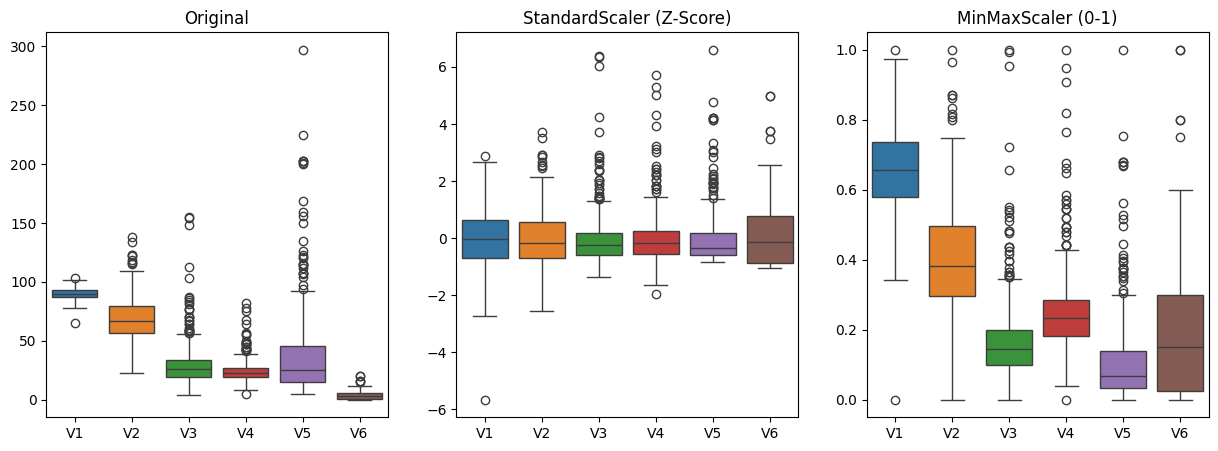

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=data_X)
plt.title('Original')

plt.subplot(1, 3, 2)
sns.boxplot(data=data_std)
plt.title('StandardScaler (Z-Score)')

plt.subplot(1, 3, 3)
sns.boxplot(data=data_minmax)
plt.title('MinMaxScaler (0-1)')

plt.show()